# Guinier Approximation

## Partilce Size and Scattering Curve

Using the sphere scattering formula, observe how the particle size affects the scattering curve.

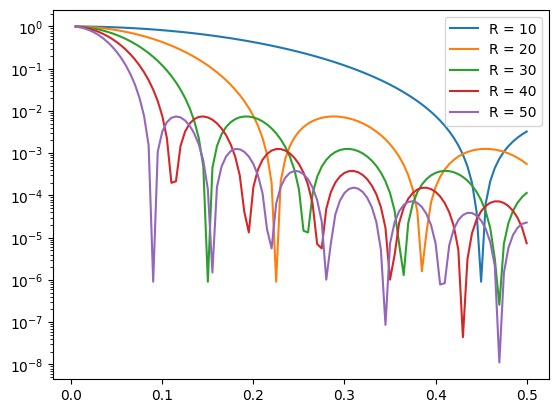

In [1]:
from molass import get_version
assert get_version() >= '0.6.1', 'Please update molass to the latest version'
import numpy as np
import matplotlib.pyplot as plt
from molass.SAXS.Models.Formfactors import homogeneous_sphere

q = np.linspace(0.005, 0.5, 100)
R = 30

I = homogeneous_sphere(q, R)
fig, ax = plt.subplots()
ax.set_yscale('log')
for R in [10, 20, 30, 40, 50]:
    I = homogeneous_sphere(q, R)
    ax.plot(q, I, label=f'R = {R}')
ax.legend();

We can observe that, in the small-angle region, the larger the particle size, the steeper the slope of the curve.

## Guinier Plot



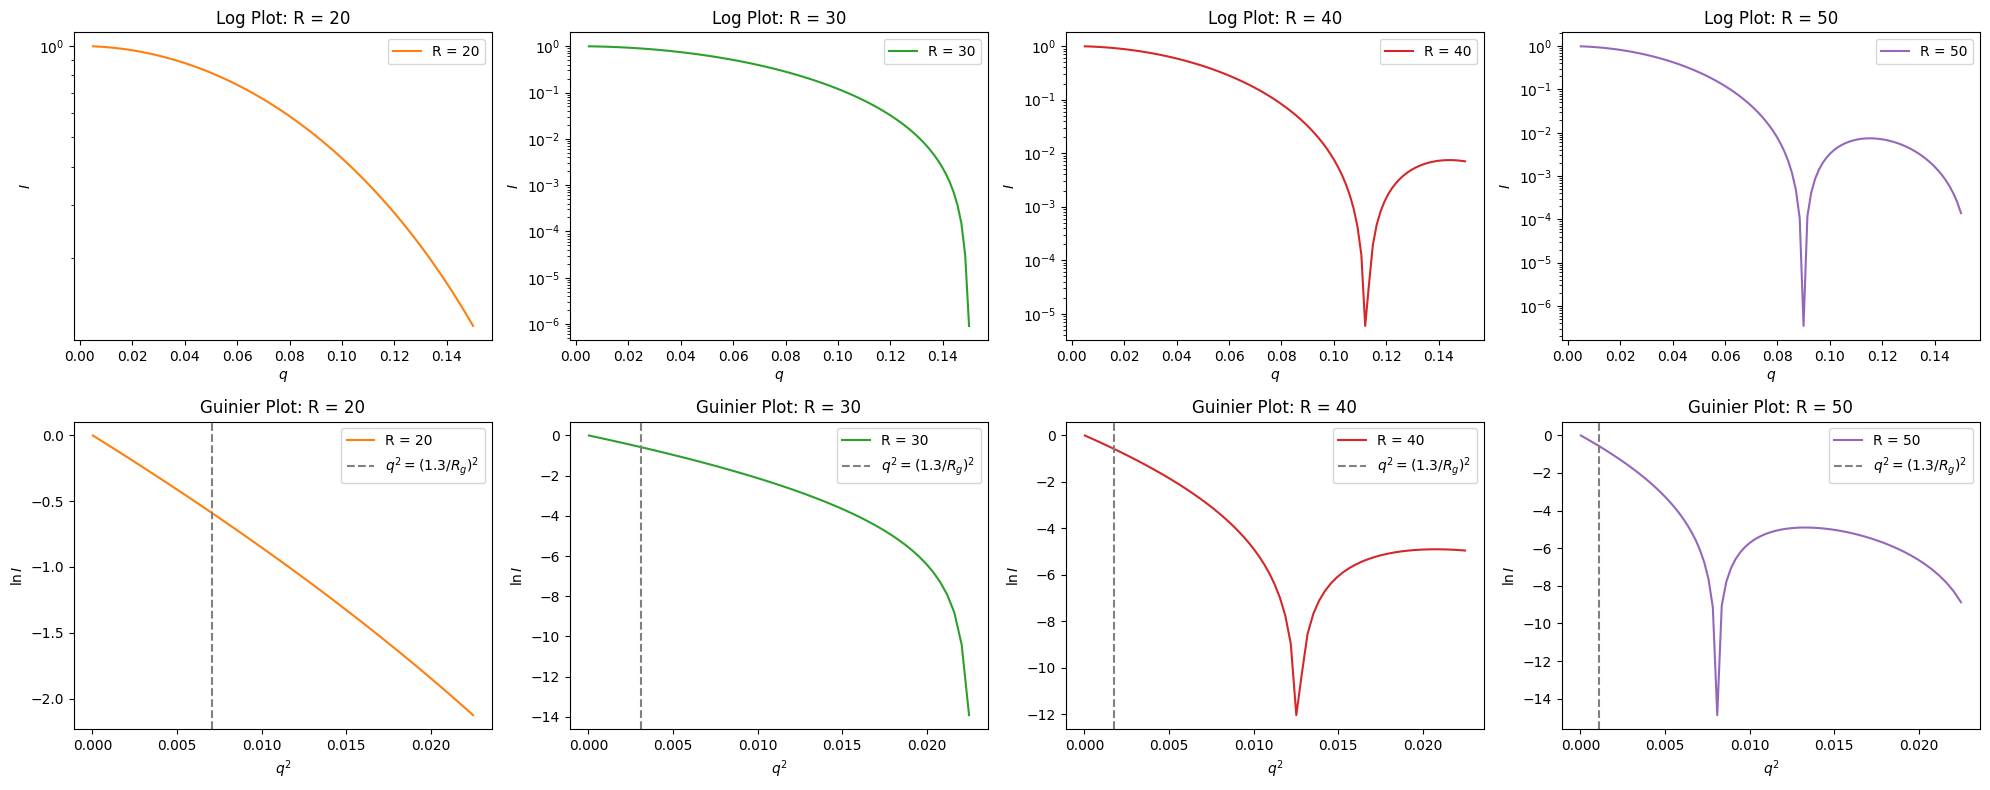

In [2]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 8))

q = np.linspace(0.005, 0.15, 100)

for j, R in enumerate([20, 30, 40, 50]):
    I = homogeneous_sphere(q, R)
    ax1, ax2= axes[:,j]
    ax1.set_title(f'Log Plot: R = {R}')
    ax1.set_xlabel(r'$q$') 
    ax1.set_ylabel(r'$I$')
    color = "C%d" % (j+1)
    ax1.plot(q, I, label=f'R = {R}', color=color)
    ax1.set_yscale('log')
    ax1.legend()
    ax2.set_title(f'Guinier Plot: R = {R}')
    ax2.plot(q**2, np.log(I), label=f'R = {R}', color=color)
    rg = R * np.sqrt(3/5)
    limit = (1.3/rg)**2
    ax2.axvline(limit, color='gray', linestyle='--', label=r'$q^2 = (1.3/R_g)^2$')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel(r'$\ln I$')
    ax2.legend()

plt.tight_layout()